<a href="https://colab.research.google.com/github/holaamigoo/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [2]:
import kagglehub
import pandas as pd

kagglehub.dataset_download("mikhailma/russian-social-media-text-classification")
df = pd.read_csv('/kaggle/input/russian-social-media-text-classification/train.csv')

df.drop('oid', inplace=True, axis=1)
df.head()

Using Colab cache for faster access to the 'russian-social-media-text-classification' dataset.


,category,text
0,winter_sport,Волшебные фото Виктория Поплавская ЕвгенияМедв...
1,extreme,Возвращение в подземелье Треша 33 Эйфория тупо...
2,football,Лучшие чешские вратари – Доминик Доминатор Гаш...
3,boardgames,Rtokenoid Warhammer40k валрак решил нас подкор...
4,hockey,Шестеркин затаскивает Рейнджерс в финал Восточ...


### Разделите данные на обучающую и валидационную выборки

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['category'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((25955,), (12785,))

### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [ ]:
# !pip install gensim

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np

def preprocess_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    return text

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        preprocessor=preprocess_text,
        lowercase=True
    )),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],  # Униграммы* или униграммы+биграммы*
    'classifier__alpha': [0.1, 0.5, 1.0, 5.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1_macro',  # Хорошая метрика для несбалансированных классов
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
display(best_model)
y_pred = best_model.predict(X_test)




Fitting 5 folds for each of 8 candidates, totalling 40 fits


Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(preprocessor=<function preprocess_text at 0x7c5d667c5940>)),
                ('classifier', MultinomialNB(alpha=0.1))])

### Вывод матрицы ошибок:

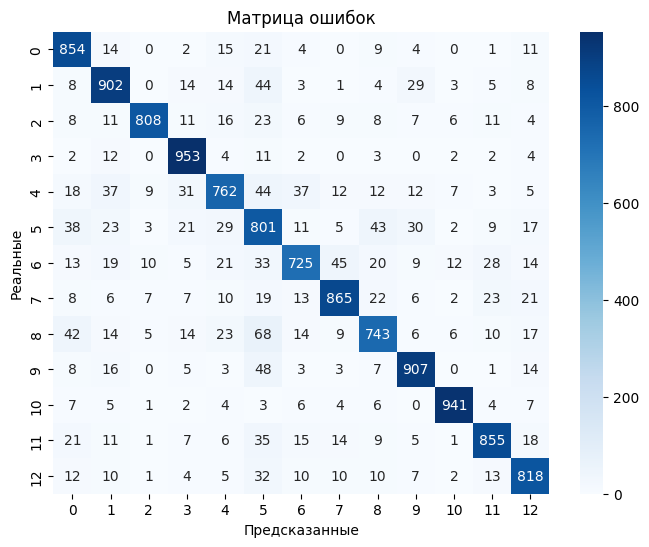

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [11]:
from sklearn.metrics import accuracy_score

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшее качество на кросс-валидации: {grid_search.best_score_:.3f}")
print(f"\nТочность на тесте: {accuracy_score(y_test, y_pred):.3f}")


Лучшие параметры: {'classifier__alpha': 0.1, 'vectorizer__ngram_range': (1, 1)}
Лучшее качество на кросс-валидации: 0.848

Точность на тесте: 0.855


## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [16]:
from sklearn.svm import LinearSVC #LinearSVC более оптимизирован
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Уменьшаем размер признакового пространства
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=10000,
        lowercase=True,
        ngram_range=(1, 2)  # Биграммы, но не больше
    )),
    ('classifier', LinearSVC(
        dual=False,  # для больших данных
        max_iter=2000,  # Ограничиваем итерации
        random_state=42
    ))
])

# Более компактная сетка параметров
param_grid = {
    'classifier__C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'classifier__loss': ['squared_hinge'],
    'classifier__penalty': ['l2']  # Только l2 для LinearSVC
}

# Уменьшаем кросс-валидацию до 3
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,  # Вместо 4
    verbose=2,
    n_jobs=-1,
    scoring='f1_macro'
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
display(best_model)
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('classifier',
                 LinearSVC(C=0.5, dual=False, max_iter=2000, random_state=42))])

### Вывод матрицы ошибок:

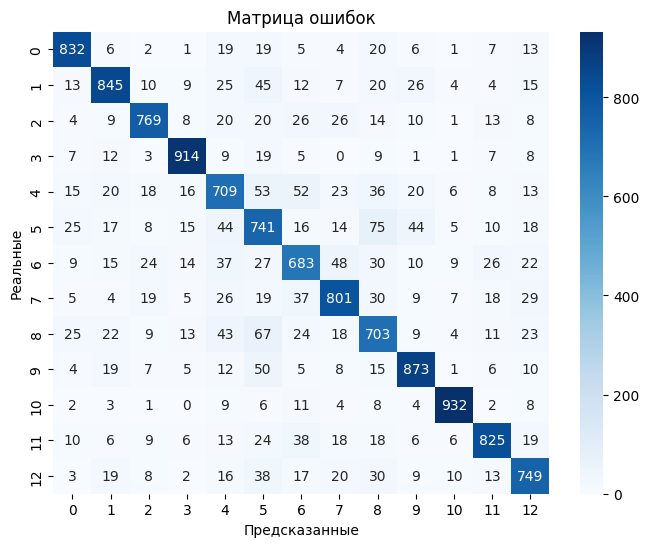

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [18]:
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Точность: {accuracy_score(y_test, y_pred):.3f}")

Лучшие параметры: {'classifier__C': 0.5, 'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2'}
Точность: 0.812


## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import numpy as np
from sklearn.metrics import accuracy_score

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=5000, #ограничиваем признаки
        lowercase=True,
        ngram_range=(1, 2)  # Добавляем биграммы
    )),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'  # Для несбалансированных классов
    ))
])


param_grid = {
    'classifier__max_depth': [10, 20, 30, None],  # Умеренные глубины
    'classifier__min_samples_split': [5, 10, 20, 50],  # Больше = меньше переобучения
    'classifier__min_samples_leaf': [2, 5, 10, 20],  # Минимальное число образцов в листе
    'classifier__max_features': ['sqrt', 'log2', None]  # Опция для контроля переобучения
}


random_search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=30,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)


random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [22]:
display(best_model)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        min_samples_leaf=2,
                                        min_samples_split=10,
                                        random_state=42))])

### Вывод матрицы ошибок:

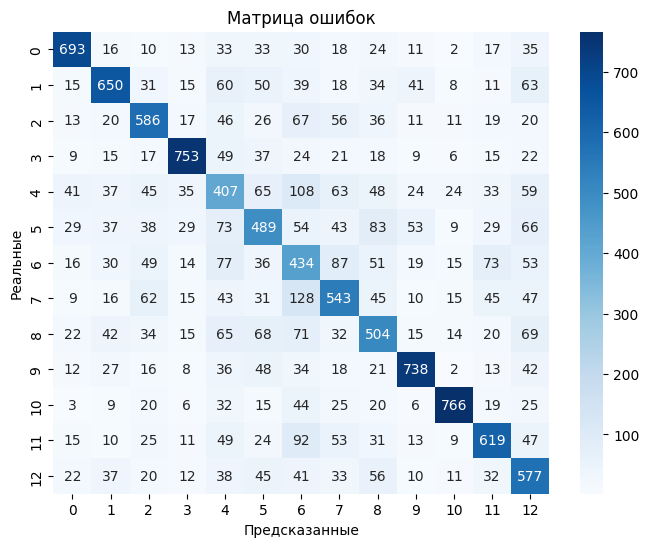

In [23]:
# Ваш код
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [25]:
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучшее качество на CV: {random_search.best_score_:.3f}")
print(f"Точность: {accuracy_score(y_test, y_pred):.3f}")

Лучшие параметры: {'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': None, 'classifier__max_depth': None}
Лучшее качество на CV: 0.580
Точность: 0.607


## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from time import time

start = time()

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=5000,
        lowercase=True,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2)
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,  # Параллельное обучение деревьев
        class_weight='balanced'
    ))
])


param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [20, 30, 40, None],
}


print(f"Всего комбинаций: {np.prod([len(v) for v in param_grid.values()])}")

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    verbose=3,
    n_jobs=-1,
    scoring='f1_macro'
)

grid_search.fit(X_train, y_train)

print(f"\nВремя выполнения: {(time() - start)/60:.1f} минут")
print(f"Лучшие параметры: {grid_search.best_params_}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Всего комбинаций: 12
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Время выполнения: 20.0 минут
Лучшие параметры: {'classifier__max_depth': None, 'classifier__n_estimators': 150}


### Вывод матрицы ошибок:

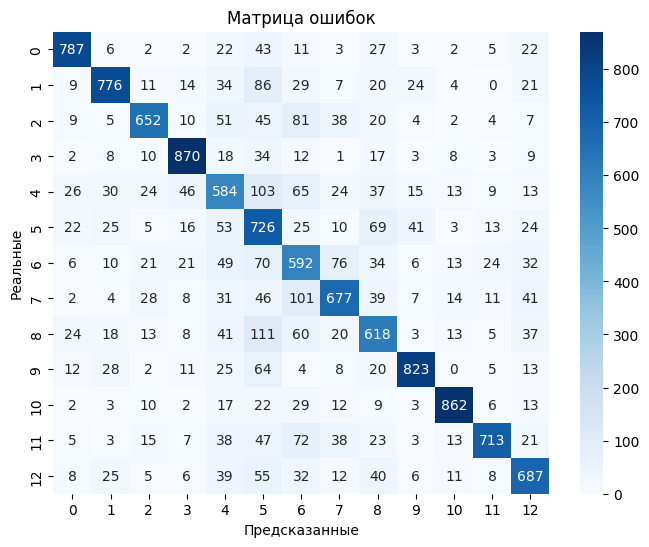

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные')
plt.ylabel('Реальные')
plt.show()

### Оценка точности:

In [34]:
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшее качество на CV: {grid_search.best_score_:.3f}")
print(f"\nТочность на тесте: {accuracy_score(y_test, y_pred):.3f}")

Лучшие параметры: {'classifier__max_depth': None, 'classifier__n_estimators': 150}
Лучшее качество на CV: 0.712

Точность на тесте: 0.733


## Подведите общие итоги и сделайте выводы

In [ ]:
# Ваш код

На подбор гиперпараметров уходило менее получаса в каждом задании благодаря настройке параметров векторизации и использования различных сеток параметров. Можно сделать вывод, что модель Наивного Байеса быстрее и лучше справляется с поставленной задачей классификации текста.

Наилучшей и самой быстрой моделью стала модель Наивного Байеса (Accuracy: 0.855).

SVM (Accuracy: 0.812) модель почти сравнялась в точности с моделью Наивного Байеса.

Деревья решений и случайный лес, хотя и дают полезную интерпретируемость и важность признаков, сильно уступают линейным моделям по времени обучения.

Модель Random Forest (Accuracy: 0.733) оказалась на третьем месте

Наихудшей оказалась модель Дерева решений (Accuracy: 0.607) с попытками подбора гиперпараметров она показывала худшие результаты. Возможно сетка была настроена неправильно.